# 🔬 Análisis Completo FAERS — Google Colab

**Dataset:** FDA Adverse Event Reporting System (FAERS) — ASCII 2025 Q4  
**Tablas:** DEMO, DRUG, REAC, OUTC, INDI, RPSR, THER  
**Variable objetivo:** Predicción de outcome fatal (muerte) dado medicamento + reacción

---
### 📋 Índice
1. Configuración del entorno
2. Carga de datos FAERS
3. Análisis Exploratorio de Datos (EDA)
4. Preprocesamiento de Datos
5. Análisis Predictivo
6. Interpretación de Resultados
7. Comunicación de Resultados

## ⚙️ 1. Configuración del entorno

In [79]:
# Instalar todas las librerías necesarias
!pip -q install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap plotly openpyxl
print('✅ Librerías instaladas correctamente')

✅ Librerías instaladas correctamente


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings, os, zipfile, shutil, urllib.request
from pathlib import Path
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Directorios de trabajo ──────────────────────────────────────────
BASE_DIR   = Path('/content/faers_eda')
DATA_DIR   = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'outputs' / 'eda_results'
for d in [DATA_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)
os.chdir(BASE_DIR)

print('📁 Base:   ', BASE_DIR)
print('📁 Data:   ', DATA_DIR)
print('📁 Outputs:', OUTPUT_DIR)

📁 Base:    /content/faers_eda
📁 Data:    /content/faers_eda/data
📁 Outputs: /content/faers_eda/outputs/eda_results


## 📥 2. Carga de datos FAERS

In [81]:
# ── Descarga directa desde FDA (2025 Q4) ───────────────────────────
# Si ya tienes los archivos .txt en data/, esta celda los detecta y no descarga de nuevo.
# Para otro trimestre cambia la URL y el nombre del ZIP.

URL_FAERS  = 'https://fis.fda.gov/content/Exports/faers_ascii_2025Q4.zip'
ZIP_LOCAL  = BASE_DIR / 'faers_ascii_2025Q4.zip'

archivos_txt = list(DATA_DIR.rglob('DEMO*.txt'))
if not archivos_txt:
    print('⬇️  Descargando FAERS ASCII 2025 Q4...')
    urllib.request.urlretrieve(URL_FAERS, ZIP_LOCAL)
    print('📦 Descomprimiendo...')
    with zipfile.ZipFile(ZIP_LOCAL, 'r') as z:
        z.extractall(DATA_DIR)
    # Mover .txt de subcarpetas al nivel raíz de data/
    for f in list(DATA_DIR.rglob('*.txt')):
        dest = DATA_DIR / f.name
        if f.resolve() != dest.resolve():
            shutil.copy2(f, dest)
    print('✅ Dataset listo en data/')
else:
    print('✅ Archivos DEMO ya existen en data/. No se descarga de nuevo.')

print('\nArchivos encontrados:')
for f in sorted(DATA_DIR.glob('*.txt')):
    print(f'  {f.name:30s}  {f.stat().st_size/1024**2:.1f} MB')

✅ Archivos DEMO ya existen en data/. No se descarga de nuevo.

Archivos encontrados:
  DELETE25Q4.txt                  0.0 MB
  DEMO25Q4.txt                    55.9 MB
  DRUG25Q4.txt                    173.6 MB
  INDI25Q4.txt                    53.4 MB
  OUTC25Q4.txt                    6.1 MB
  REAC25Q4.txt                    48.8 MB
  RPSR25Q4.txt                    0.2 MB
  THER25Q4.txt                    15.9 MB


In [82]:
# ── Función de carga con detección automática del trimestre ─────────
SEP      = '$'
ENCODING = 'latin-1'

def cargar(patron_glob, nrows=None):
    """Carga la primera coincidencia del patrón glob dentro de DATA_DIR."""
    rutas = sorted(DATA_DIR.glob(patron_glob))
    if not rutas:
        raise FileNotFoundError(f'No se encontró ningún archivo con patrón {patron_glob} en {DATA_DIR}')
    ruta = rutas[0]
    df = pd.read_csv(ruta, sep=SEP, encoding=ENCODING, low_memory=False, nrows=nrows)
    df.columns = df.columns.str.strip().str.lower()
    return df

# ── Cargar tablas principales ────────────────────────────────────────
print('Cargando tablas FAERS...')
demo = cargar('DEMO*.txt')
drug = cargar('DRUG*.txt')
reac = cargar('REAC*.txt')
outc = cargar('OUTC*.txt')

print(f'✅ DEMO  {demo.shape[0]:>8,} filas  {demo.shape[1]} cols')
print(f'✅ DRUG  {drug.shape[0]:>8,} filas  {drug.shape[1]} cols')
print(f'✅ REAC  {reac.shape[0]:>8,} filas  {reac.shape[1]} cols')
print(f'✅ OUTC  {outc.shape[0]:>8,} filas  {outc.shape[1]} cols')

Cargando tablas FAERS...
✅ DEMO   385,288 filas  25 cols
✅ DRUG  1,815,349 filas  20 cols
✅ REAC  1,349,105 filas  4 cols
✅ OUTC   289,721 filas  3 cols


---
## 📊 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Visualización de Datos

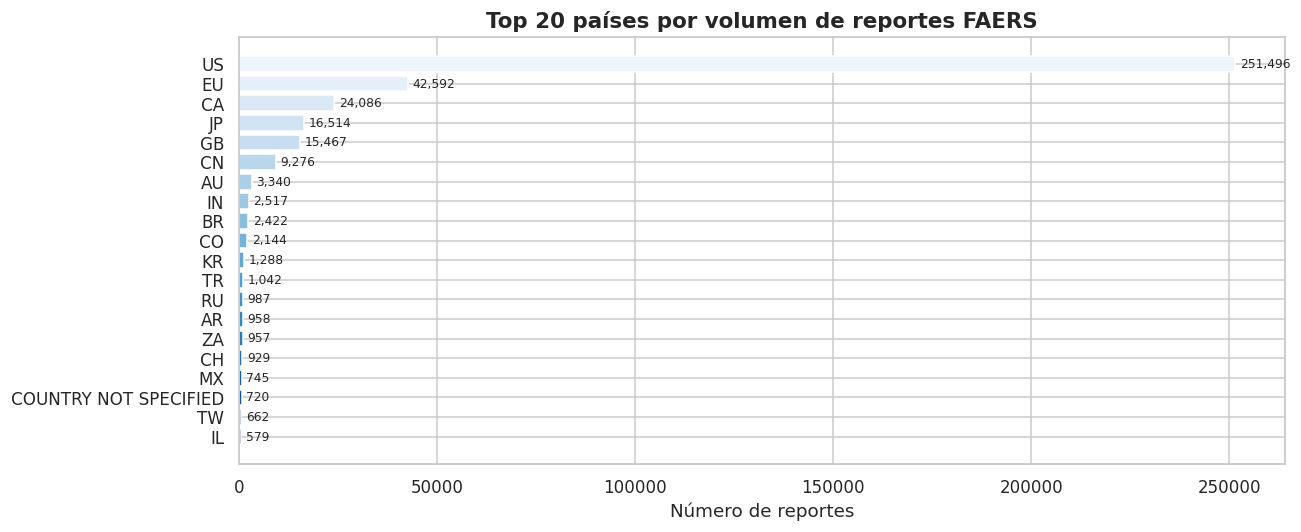

In [83]:
# Top 20 países por número de reportes
top_paises = demo['reporter_country'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_paises.index[::-1], top_paises.values[::-1], color=sns.color_palette('Blues_r', 20))
ax.set_xlabel('Número de reportes')
ax.set_title('Top 20 países por volumen de reportes FAERS', fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_top_paises.png')
plt.show()

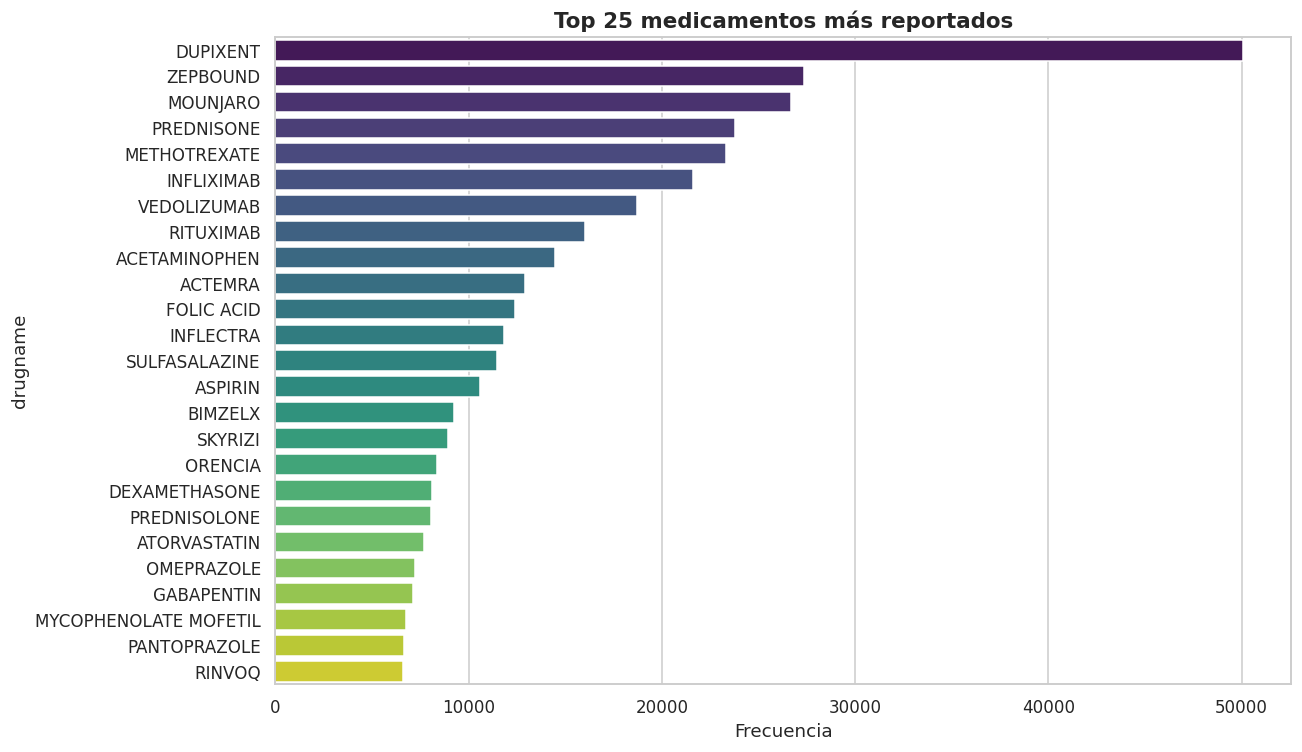

In [84]:
# Top 25 medicamentos más reportados
top_drugs = drug['drugname'].str.upper().value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(y=top_drugs.index, x=top_drugs.values, palette='viridis', ax=ax)
ax.set_xlabel('Frecuencia')
ax.set_title('Top 25 medicamentos más reportados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_top_drugs.png')
plt.show()

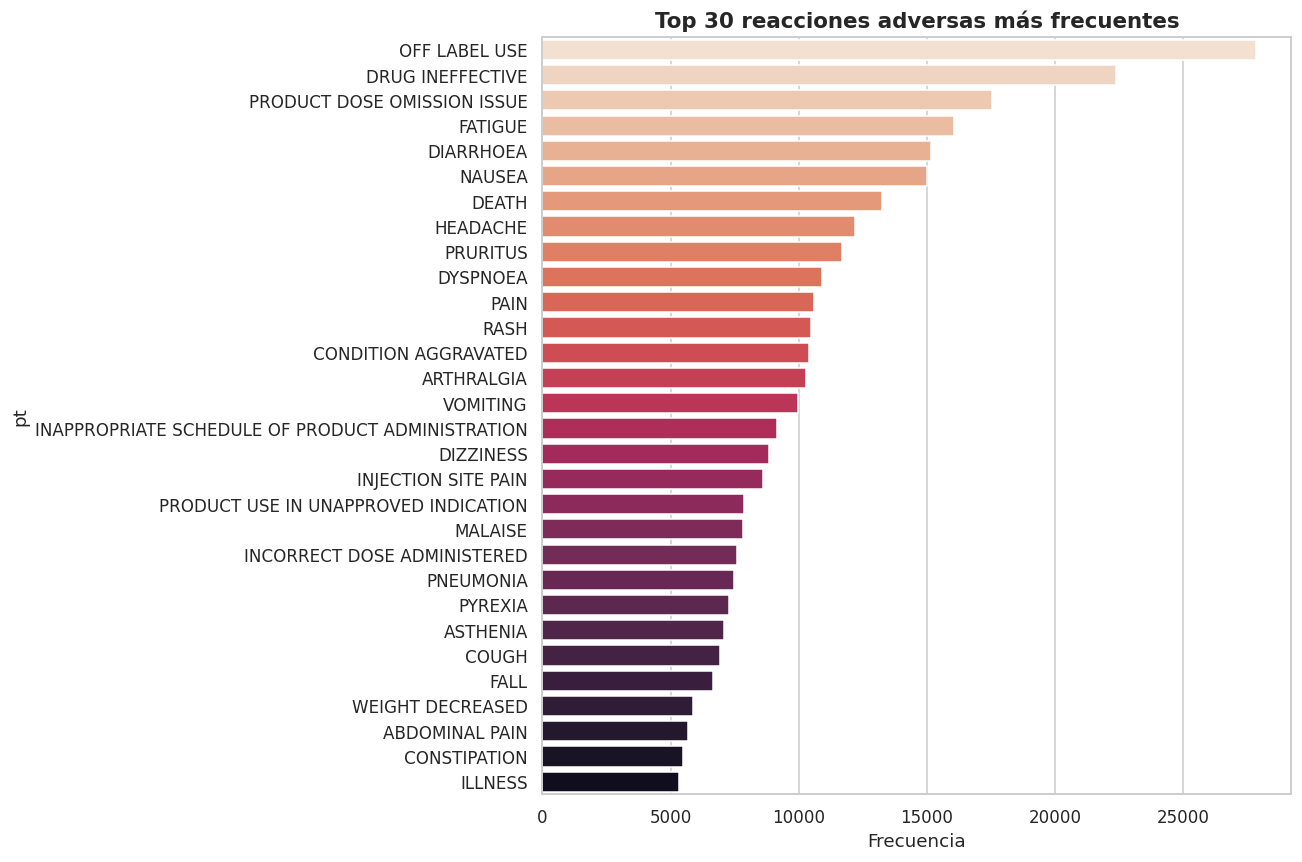

In [85]:
# Top 30 reacciones adversas más frecuentes
top_reac = reac['pt'].str.upper().value_counts().head(30)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(y=top_reac.index, x=top_reac.values, palette='rocket_r', ax=ax)
ax.set_xlabel('Frecuencia')
ax.set_title('Top 30 reacciones adversas más frecuentes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_top_reacciones.png')
plt.show()

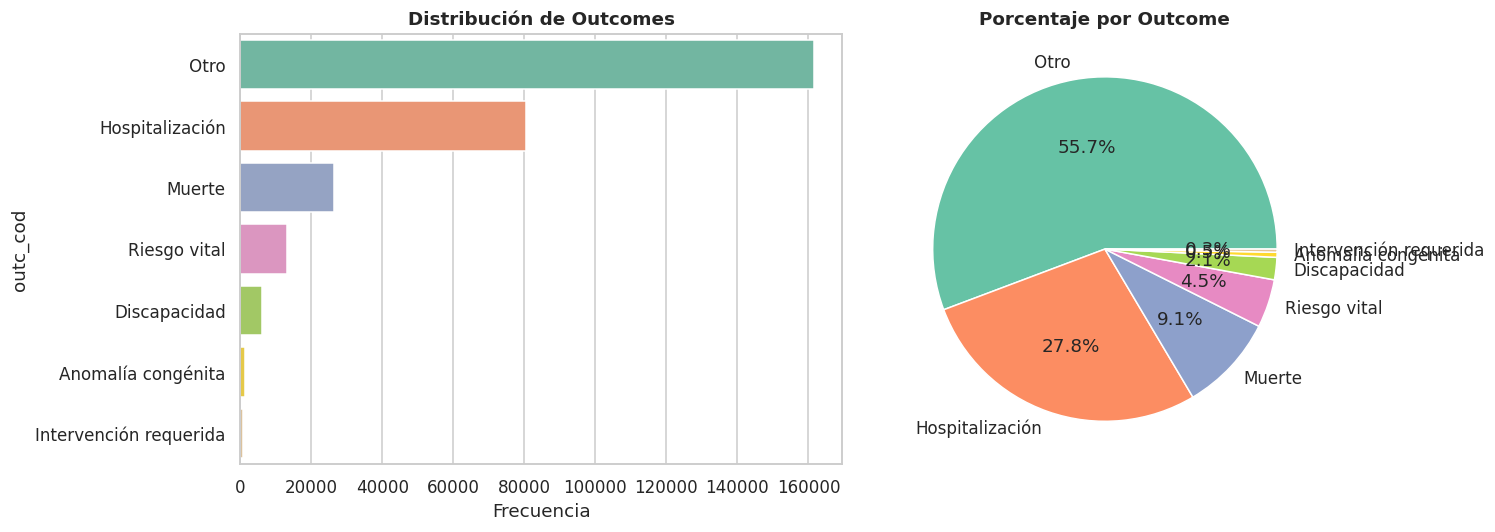

In [86]:
# Distribución de outcomes
outcome_labels = {
    'DE': 'Muerte', 'LT': 'Riesgo vital', 'HO': 'Hospitalización',
    'DS': 'Discapacidad', 'CA': 'Anomalía congénita',
    'RI': 'Intervención requerida', 'OT': 'Otro'
}
outc_counts = outc['outc_cod'].map(outcome_labels).fillna('Desconocido').value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras
sns.barplot(y=outc_counts.index, x=outc_counts.values, palette='Set2', ax=axes[0])
axes[0].set_xlabel('Frecuencia')
axes[0].set_title('Distribución de Outcomes', fontweight='bold')

# Pie
axes[1].pie(outc_counts.values, labels=outc_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(outc_counts)))
axes[1].set_title('Porcentaje por Outcome', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_outcomes.png')
plt.show()

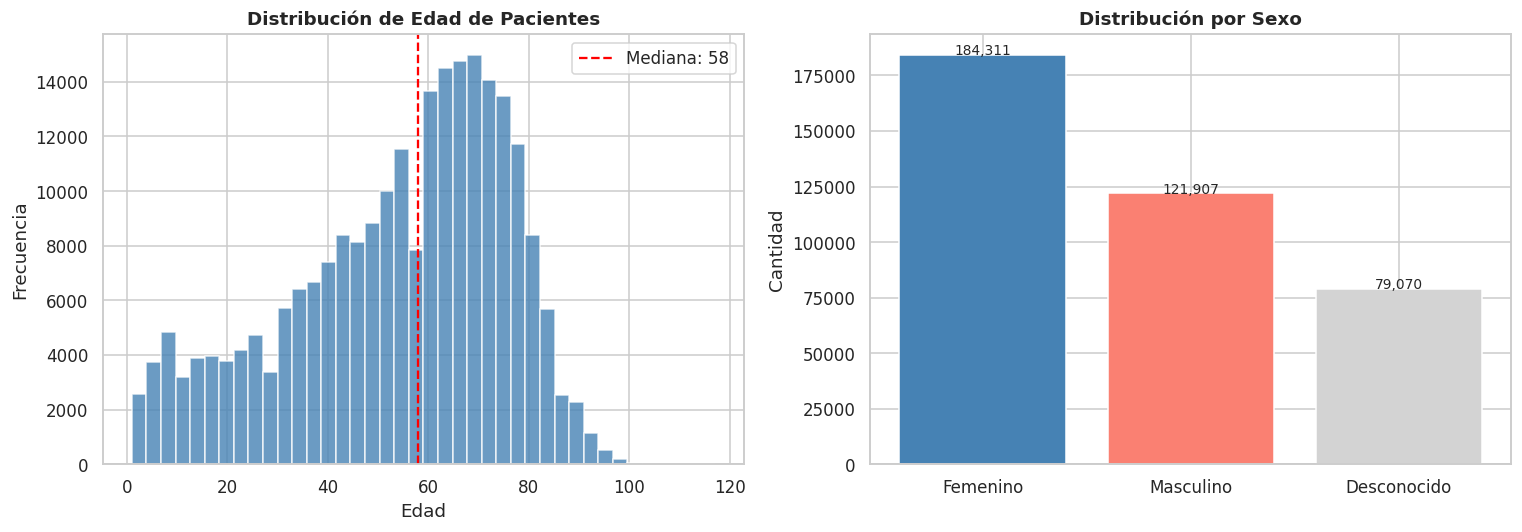

In [87]:
# Distribución de edad y sexo
demo_clean = demo[demo['age'].notna() & (demo['age'] > 0) & (demo['age'] < 120)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma edad
axes[0].hist(demo_clean['age'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(demo_clean['age'].median(), color='red', linestyle='--', label=f"Mediana: {demo_clean['age'].median():.0f}")
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Edad de Pacientes', fontweight='bold')
axes[0].legend()

# Distribución por sexo
sex_map = {'M': 'Masculino', 'F': 'Femenino', 'UNK': 'Desconocido'}
sex_counts = demo['sex'].map(sex_map).fillna('Desconocido').value_counts()
axes[1].bar(sex_counts.index, sex_counts.values,
            color=['steelblue', 'salmon', 'lightgray'])
axes[1].set_ylabel('Cantidad')
axes[1].set_title('Distribución por Sexo', fontweight='bold')
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'viz_edad_sexo.png')
plt.show()

### 3.2 Resumen Estadístico

In [88]:
print('='*60)
print('RESUMEN ESTADÍSTICO — TABLA DEMO')
print('='*60)
display(demo.describe(include='all').T)

print('\n' + '='*60)
print('VALORES NULOS POR COLUMNA (DEMO)')
print('='*60)
nulos = demo.isnull().sum()
pct   = (nulos / len(demo) * 100).round(1)
resumen_nulos = pd.DataFrame({'Nulos': nulos, '%': pct}).query('Nulos > 0').sort_values('%', ascending=False)
display(resumen_nulos)

# Guardar resumen
resumen_nulos.to_csv(OUTPUT_DIR / 'resumen_nulos_demo.csv')
print('\n💾 Guardado: resumen_nulos_demo.csv')

RESUMEN ESTADÍSTICO — TABLA DEMO


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
primaryid,385288.0,NaN,NaN,NaN,281875018.739618,219180418.415227,42021115.0,258938228.5,260034596.0,261157613.75,21684576150.0
caseid,385288.0,NaN,NaN,NaN,25713758.771111,1247254.322822,4202111.0,25888246.75,25997841.5,26110125.25,26233083.0
caseversion,385288.0,NaN,NaN,NaN,1.791725,2.599979,1.0,1.0,1.0,2.0,151.0
i_f_code,385288,2,I,263813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_dt,172235.0,NaN,NaN,NaN,20243258.555079,24370.104595,19200901.0,20250101.0,20250601.0,20251002.0,20261118.0
mfr_dt,385288.0,NaN,NaN,NaN,20250533.418461,5666.874917,20000215.0,20251009.0,20251105.0,20251201.0,20350603.0
init_fda_dt,385288.0,NaN,NaN,NaN,20249451.115817,7879.802729,20040902.0,20251007.0,20251105.0,20251201.0,20251231.0
fda_dt,385288.0,NaN,NaN,NaN,20251119.363655,82.559415,20250919.0,20251027.0,20251117.0,20251210.0,20251231.0
rept_cod,385288,5,EXP,202029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
auth_num,36225,28951,GB-MHRA-MED-202511191154444500-WSHLJ,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN



VALORES NULOS POR COLUMNA (DEMO)


,Nulos,%
to_mfr,373831,97.0
lit_ref,352373,91.5
auth_num,349063,90.6
wt_cod,320623,83.2
wt,320623,83.2
age_grp,244802,63.5
event_dt,213053,55.3
age,147796,38.4
age_cod,147784,38.4
sex,79070,20.5



💾 Guardado: resumen_nulos_demo.csv


In [89]:
# Resumen general de todas las tablas
tablas = {'DEMO': demo, 'DRUG': drug, 'REAC': reac, 'OUTC': outc}
filas_resumen = []
for nombre, df in tablas.items():
    filas_resumen.append({
        'Tabla': nombre,
        'Filas': df.shape[0],
        'Columnas': df.shape[1],
        '% Nulos': round(df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100, 2),
        'Duplicados': df.duplicated().sum()
    })

resumen_tablas = pd.DataFrame(filas_resumen)
resumen_tablas.to_csv(OUTPUT_DIR / 'resumen_tablas.csv', index=False)
display(resumen_tablas)

,Tabla,Filas,Columnas,% Nulos,Duplicados
0,DEMO,385288,25,27.70,0
1,DRUG,1815349,20,44.28,1035
2,REAC,1349105,4,24.97,16270
3,OUTC,289721,3,0.00,0


### 3.3 Identificación de Valores Atípicos (Outliers)

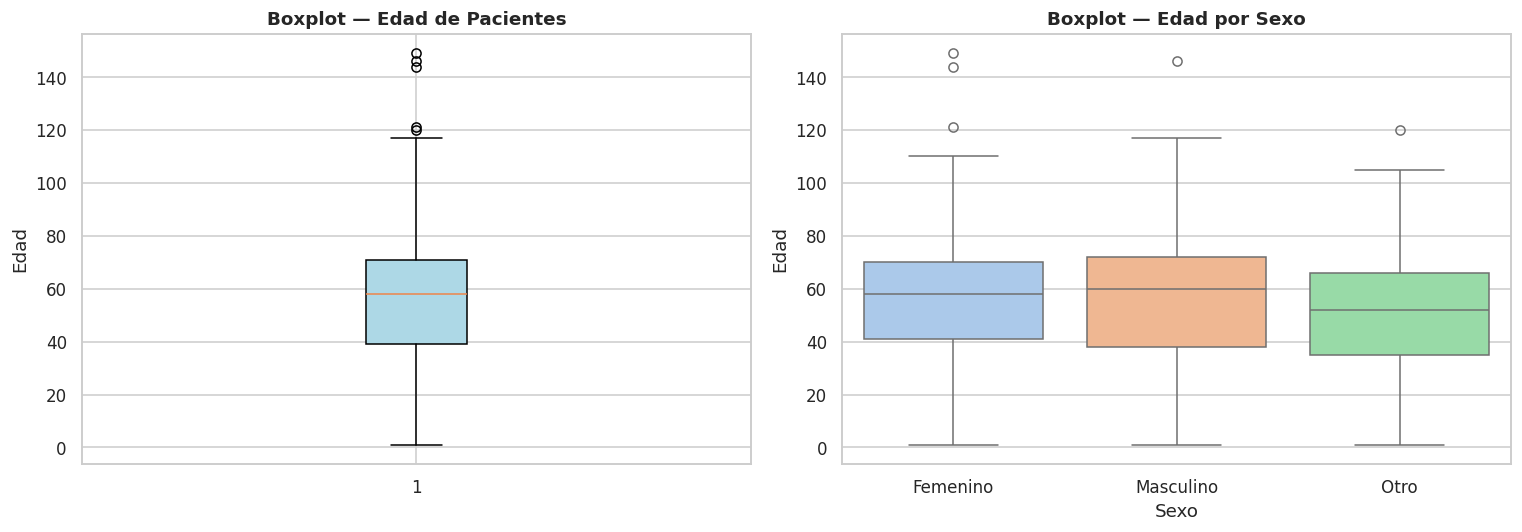

Q1=39.0  Q3=71.0  IQR=32.0
Límite inferior IQR: -9.0
Límite superior IQR: 119.0
Outliers detectados: 5 (0.0%)


In [90]:
demo_valid = demo[demo['age'].notna() & (demo['age'] > 0) & (demo['age'] < 150)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot edad
axes[0].boxplot(demo_valid['age'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_ylabel('Edad')
axes[0].set_title('Boxplot — Edad de Pacientes', fontweight='bold')

# Boxplot por sexo
demo_valid['sex_label'] = demo_valid['sex'].map({'M':'Masculino','F':'Femenino'}).fillna('Otro')
sns.boxplot(data=demo_valid, x='sex_label', y='age', palette='pastel', ax=axes[1])
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Edad')
axes[1].set_title('Boxplot — Edad por Sexo', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'outliers_edad.png')
plt.show()

# Cálculo IQR
Q1 = demo_valid['age'].quantile(0.25)
Q3 = demo_valid['age'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
outliers_edad = demo_valid[(demo_valid['age'] < lim_inf) | (demo_valid['age'] > lim_sup)]

print(f'Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}')
print(f'Límite inferior IQR: {lim_inf:.1f}')
print(f'Límite superior IQR: {lim_sup:.1f}')
print(f'Outliers detectados: {len(outliers_edad):,} ({len(outliers_edad)/len(demo_valid)*100:.1f}%)')

### 3.4 Correlación entre Variables

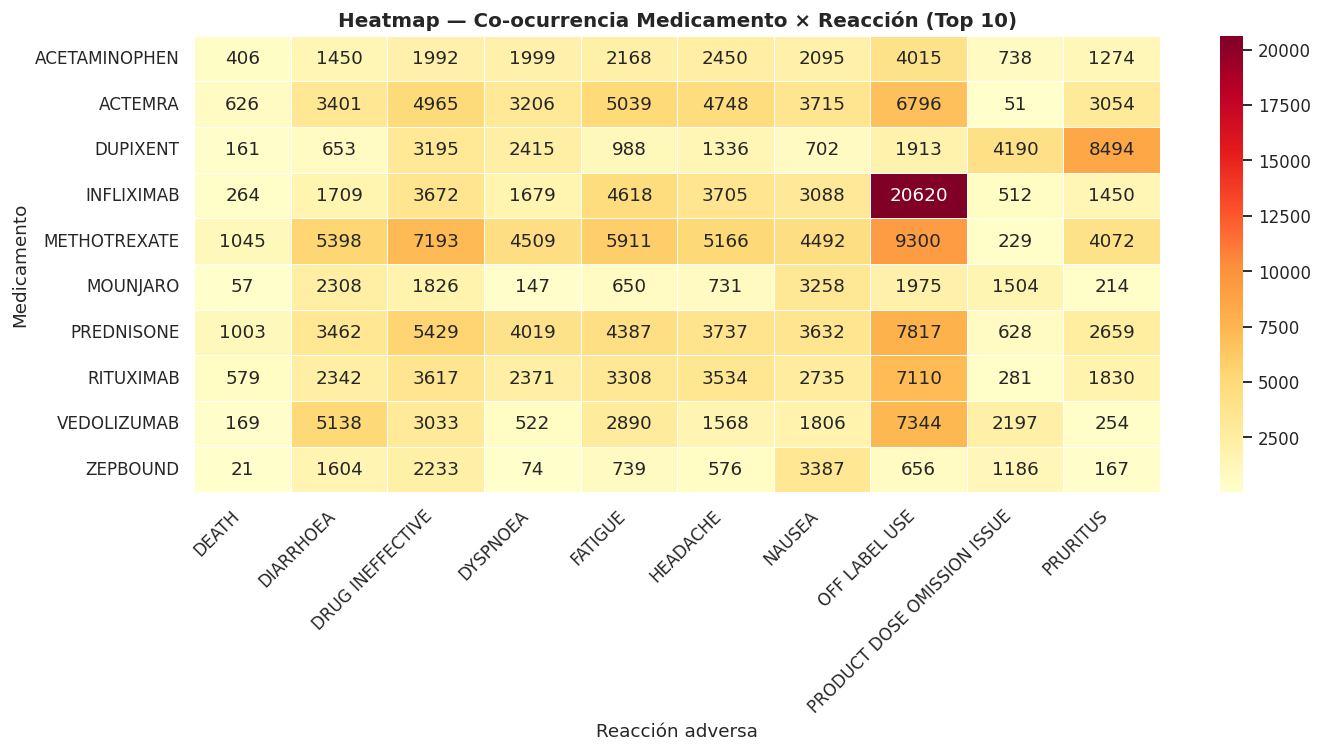

In [91]:
# Heatmap droga × reacción (top 10 de cada uno)
top10_drugs = drug['drugname'].str.upper().value_counts().head(10).index
top10_reac  = reac['pt'].str.upper().value_counts().head(10).index

drug_filt = drug[drug['drugname'].str.upper().isin(top10_drugs)][['primaryid','drugname']].copy()
drug_filt['drugname'] = drug_filt['drugname'].str.upper()
reac_filt = reac[reac['pt'].str.upper().isin(top10_reac)][['primaryid','pt']].copy()
reac_filt['pt'] = reac_filt['pt'].str.upper()

merged = pd.merge(drug_filt, reac_filt, on='primaryid')
pivot  = merged.groupby(['drugname','pt']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Heatmap — Co-ocurrencia Medicamento × Reacción (Top 10)', fontsize=13, fontweight='bold')
ax.set_xlabel('Reacción adversa')
ax.set_ylabel('Medicamento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'heatmap_drug_reac.png')
plt.show()

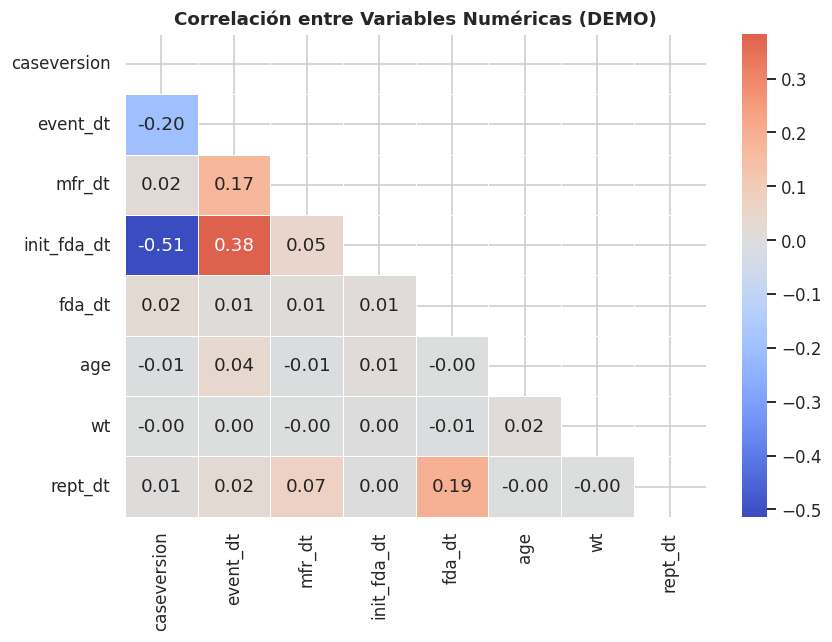

In [92]:
# Correlación entre variables numéricas de DEMO
numericas = demo.select_dtypes(include='number').drop(columns=['primaryid','caseid'], errors='ignore')
if numericas.shape[1] >= 2:
    corr = numericas.corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.5, ax=ax)
    ax.set_title('Correlación entre Variables Numéricas (DEMO)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'correlacion_numericas.png')
    plt.show()
else:
    print('No hay suficientes columnas numéricas para calcular correlación en DEMO.')

### 3.5 Imputación de Datos Faltantes

In [93]:
from sklearn.impute import SimpleImputer

demo_imp = demo.copy()

# Numérica: edad → mediana
imp_num = SimpleImputer(strategy='median')
demo_imp['age'] = imp_num.fit_transform(demo_imp[['age']])

# Categórica: sexo, ocupación → moda
for col in ['sex', 'occp_cod', 'reporter_country']:
    if col in demo_imp.columns:
        moda = demo_imp[col].mode()[0]
        demo_imp[col] = demo_imp[col].fillna(moda)

# Comparativa antes/después
cols_check = [c for c in ['age','sex','occp_cod','reporter_country'] if c in demo.columns]
comparativa = pd.DataFrame({
    'Antes (nulos)': demo[cols_check].isnull().sum(),
    'Después (nulos)': demo_imp[cols_check].isnull().sum()
})
display(comparativa)
print('\n✅ Imputación completada. demo_imp listo.')

,Antes (nulos),Después (nulos)
age,147796,0
sex,79070,0
occp_cod,77118,0
reporter_country,1,0



✅ Imputación completada. demo_imp listo.


### 3.6 Segmentación y Agrupamiento

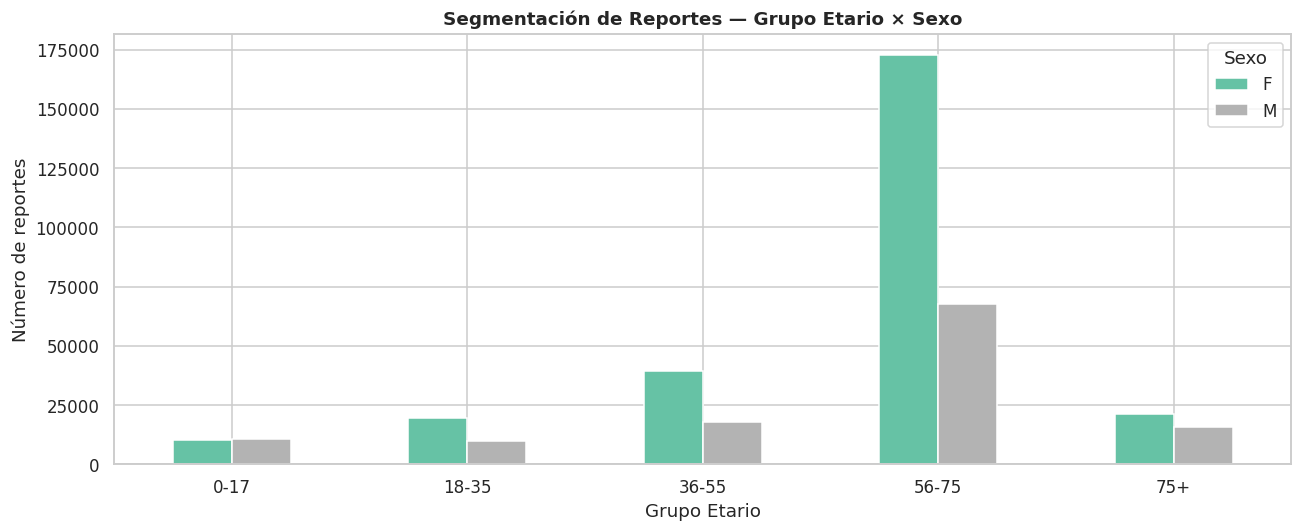

grupo_etario,0-17,18-35,36-55,56-75,75+
reporter_country,,,,,
CA,850,2167,5139,13611,2317
EU,2478,3791,7334,23269,5656
GB,502,1374,2404,9741,1444
JP,3045,517,1616,8528,2797
US,11629,18281,34037,165556,21917


In [94]:
# Grupos etarios
bins   = [0, 17, 35, 55, 75, 150]
labels = ['0-17', '18-35', '36-55', '56-75', '75+']
demo_imp['grupo_etario'] = pd.cut(demo_imp['age'], bins=bins, labels=labels, right=True)

# Segmentación por sexo y grupo etario
seg = demo_imp.groupby(['grupo_etario','sex']).size().unstack(fill_value=0)

seg.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='white')
plt.title('Segmentación de Reportes — Grupo Etario × Sexo', fontweight='bold')
plt.xlabel('Grupo Etario')
plt.ylabel('Número de reportes')
plt.legend(title='Sexo')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'segmentacion_etario_sexo.png')
plt.show()

# Segmentación top 5 países
top5_paises = demo_imp['reporter_country'].value_counts().head(5).index
seg_pais = demo_imp[demo_imp['reporter_country'].isin(top5_paises)]
seg_pais_grp = seg_pais.groupby(['reporter_country','grupo_etario']).size().unstack(fill_value=0)
display(seg_pais_grp)
seg_pais_grp.to_csv(OUTPUT_DIR / 'segmentacion_pais_etario.csv')

### 3.7 Análisis de Tendencias Temporales

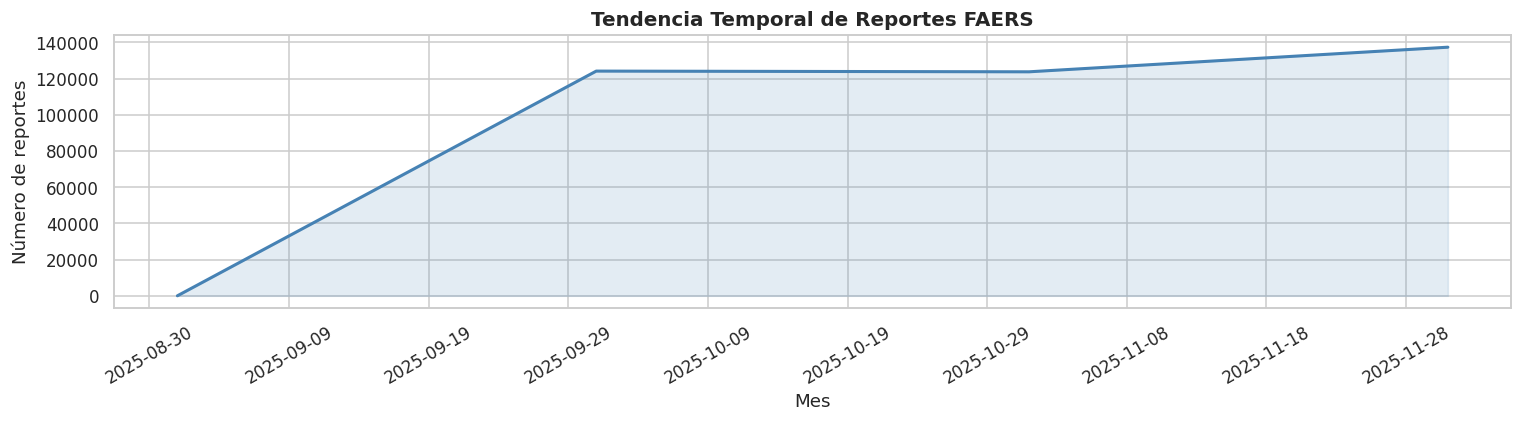

In [95]:
# Columna de fecha: 'fda_dt' o 'event_dt' según el trimestre
col_fecha = next((c for c in ['fda_dt','event_dt','rept_dt'] if c in demo.columns), None)

if col_fecha:
    demo_t = demo.copy()
    demo_t['fecha'] = pd.to_datetime(demo_t[col_fecha], format='%Y%m%d', errors='coerce')
    demo_t = demo_t[demo_t['fecha'].notna()]
    demo_t['mes'] = demo_t['fecha'].dt.to_period('M')

    tendencia = demo_t.groupby('mes').size().reset_index(name='reportes')
    tendencia['mes_ts'] = tendencia['mes'].dt.to_timestamp()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(tendencia['mes_ts'], tendencia['reportes'], color='steelblue', linewidth=2)
    ax.fill_between(tendencia['mes_ts'], tendencia['reportes'], alpha=0.15, color='steelblue')
    ax.set_title('Tendencia Temporal de Reportes FAERS', fontweight='bold', fontsize=13)
    ax.set_xlabel('Mes')
    ax.set_ylabel('Número de reportes')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'tendencia_temporal.png')
    plt.show()
else:
    print(f'Columna de fecha no encontrada. Columnas disponibles: {list(demo.columns)}')

---
## 🔧 4. Preprocesamiento de Datos

### 4.1 Limpieza de Datos

In [96]:
# ── Unir tablas: DEMO + OUTC para construir dataset de modelado ──────
outc_fatal = outc[['primaryid','outc_cod']].copy()
outc_fatal['fatal'] = (outc_fatal['outc_cod'] == 'DE').astype(int)
outc_flag = outc_fatal.groupby('primaryid')['fatal'].max().reset_index()

df_model = demo_imp.merge(outc_flag, on='primaryid', how='inner')

print(f'Dataset combinado: {df_model.shape[0]:,} filas, {df_model.shape[1]} columnas')
print(f'Distribución de variable objetivo (fatal):')
print(df_model['fatal'].value_counts(normalize=True).map('{:.1%}'.format))

# ── Limpieza ─────────────────────────────────────────────────────────
# Eliminar duplicados por primaryid (caso único)
antes = len(df_model)
df_model = df_model.drop_duplicates(subset='primaryid')
print(f'\nDuplicados eliminados: {antes - len(df_model):,}')

# Eliminar edades inválidas
df_model = df_model[(df_model['age'] >= 0) & (df_model['age'] <= 120)]
print(f'Filas tras filtro de edad: {len(df_model):,}')

# Estandarizar sexo
df_model['sex'] = df_model['sex'].str.upper().str.strip()
df_model['sex'] = df_model['sex'].where(df_model['sex'].isin(['M','F']), other='UNK')

print('\n✅ Limpieza completada.')
df_model[['primaryid','age','sex','reporter_country','grupo_etario','fatal']].head()

Dataset combinado: 218,342 filas, 27 columnas
Distribución de variable objetivo (fatal):
fatal
0    88.0%
1    12.0%
Name: proportion, dtype: object

Duplicados eliminados: 0
Filas tras filtro de edad: 218,276

✅ Limpieza completada.


,primaryid,age,sex,reporter_country,grupo_etario,fatal
0,100324053,7.0,F,CA,0-17,1
1,1012809821,19.0,F,CA,18-35,0
2,101406268,30.0,F,US,18-35,0
3,101515934,61.0,F,EU,56-75,0
4,1016133068,66.0,F,CA,56-75,0


### 4.2 Selección de Características

In [97]:
from sklearn.feature_selection import chi2, SelectKBest

# Características candidatas
FEATURES_CAT = [c for c in ['sex', 'occp_cod', 'reporter_country', 'mfr_sndr', 'rept_cod'] if c in df_model.columns]
FEATURE_NUM  = ['age']

print('Características seleccionadas:')
print(f'  Numéricas  : {FEATURE_NUM}')
print(f'  Categóricas: {FEATURES_CAT}')

# Valores nulos en features
for col in FEATURE_NUM + FEATURES_CAT:
    pct = df_model[col].isnull().mean() * 100
    print(f'  {col:25s}: {pct:.1f}% nulos')

Características seleccionadas:
  Numéricas  : ['age']
  Categóricas: ['sex', 'occp_cod', 'reporter_country', 'mfr_sndr', 'rept_cod']
  age                      : 0.0% nulos
  sex                      : 0.0% nulos
  occp_cod                 : 0.0% nulos
  reporter_country         : 0.0% nulos
  mfr_sndr                 : 0.0% nulos
  rept_cod                 : 0.0% nulos


### 4.3 Transformación de Datos

In [98]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_enc = df_model.copy()

# Codificar variables categóricas con Label Encoding
encoders = {}
for col in FEATURES_CAT:
    le = LabelEncoder()
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col].fillna('UNK').astype(str))
    encoders[col] = le

# Escalar edad
scaler = StandardScaler()
df_enc['age_scaled'] = scaler.fit_transform(df_enc[['age']])

# Grupo etario → ordinal
grup_map = {'0-17': 0, '18-35': 1, '36-55': 2, '56-75': 3, '75+': 4}
df_enc['grupo_etario_ord'] = df_enc['grupo_etario'].map(grup_map).fillna(2)

FEATURES_FINAL = ['age_scaled', 'grupo_etario_ord'] + [c + '_enc' for c in FEATURES_CAT]
print('✅ Features finales:', FEATURES_FINAL)
df_enc[FEATURES_FINAL + ['fatal']].head()

✅ Features finales: ['age_scaled', 'grupo_etario_ord', 'sex_enc', 'occp_cod_enc', 'reporter_country_enc', 'mfr_sndr_enc', 'rept_cod_enc']


,age_scaled,grupo_etario_ord,sex_enc,occp_cod_enc,reporter_country_enc,mfr_sndr_enc,rept_cod_enc,fatal
0,-2.732083,0,0,0,23,71,3,1
1,-2.063635,1,0,3,23,484,3,0
2,-1.450891,1,0,0,122,93,3,0
3,0.275933,3,0,1,39,484,3,0
4,0.554452,3,0,0,23,484,3,0


### 4.4 Manejo de Datos Desbalanceados

Distribución ANTES de SMOTE: Counter({np.int64(0): 191986, np.int64(1): 26290})
% Fatal: 12.0%
Distribución DESPUÉS de SMOTE: Counter({np.int64(1): 191986, np.int64(0): 191986})


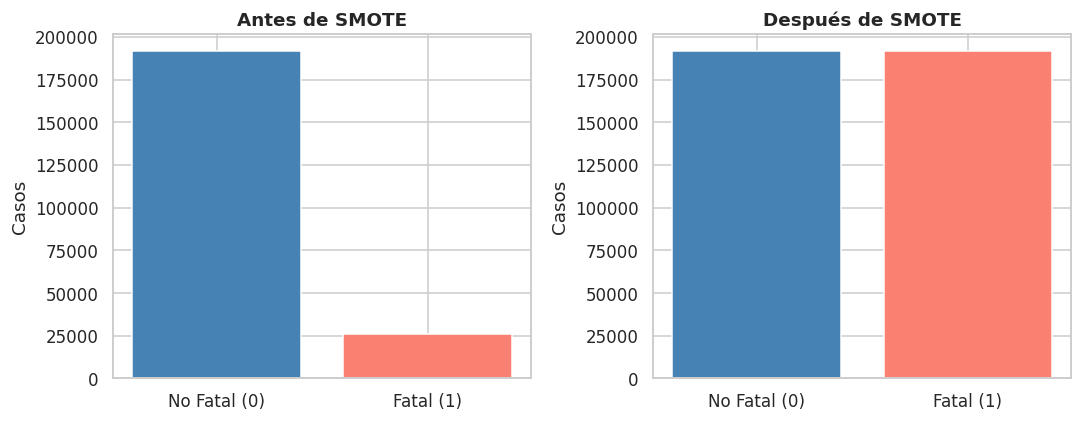

In [99]:
from imblearn.over_sampling import SMOTE
from collections import Counter

X_raw = df_enc[FEATURES_FINAL].values
y_raw = df_enc['fatal'].values

print('Distribución ANTES de SMOTE:', Counter(y_raw))
ratio_fatal = y_raw.sum() / len(y_raw)
print(f'% Fatal: {ratio_fatal:.1%}')

# Aplicar SMOTE solo si hay desbalance significativo (< 30% clase minoritaria)
if ratio_fatal < 0.30:
    smote = SMOTE(random_state=42, k_neighbors=min(5, Counter(y_raw)[1]-1))
    X_bal, y_bal = smote.fit_resample(X_raw, y_raw)
    print('Distribución DESPUÉS de SMOTE:', Counter(y_bal))
else:
    X_bal, y_bal = X_raw, y_raw
    print('Dataset suficientemente balanceado. No se aplica SMOTE.')

# Visualización del balance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, titulo) in zip(axes, [(y_raw, 'Antes de SMOTE'), (y_bal, 'Después de SMOTE')]):
    vals = Counter(data)
    ax.bar(['No Fatal (0)', 'Fatal (1)'], [vals[0], vals[1]], color=['steelblue','salmon'])
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Casos')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'balance_clases.png')
plt.show()

### 4.5 División de Datos

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.20, random_state=42, stratify=y_bal
)

print(f'Train: {X_train.shape[0]:,} muestras  ({X_train.shape[0]/len(X_bal):.0%})')
print(f'Test:  {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(X_bal):.0%})')
print(f'Train fatal%: {y_train.mean():.1%}')
print(f'Test  fatal%: {y_test.mean():.1%}')

Train: 307,177 muestras  (80%)
Test:  76,795 muestras  (20%)
Train fatal%: 50.0%
Test  fatal%: 50.0%


### 4.6 Manejo de Datos Categóricos

In [101]:
# Resumen del encoding aplicado
print('Codificación de variables categóricas aplicada:\n')
for col, le in encoders.items():
    n_clases = len(le.classes_)
    print(f'  {col:25s}: {n_clases} categorías  → Label Encoding')

print('\nEjemplo: Sex encoder')
if 'sex' in encoders:
    for cls, idx in zip(encoders['sex'].classes_, encoders['sex'].transform(encoders['sex'].classes_)):
        print(f'  "{cls}" → {idx}')

Codificación de variables categóricas aplicada:

  sex                      : 2 categorías  → Label Encoding
  occp_cod                 : 5 categorías  → Label Encoding
  reporter_country         : 132 categorías  → Label Encoding
  mfr_sndr                 : 629 categorías  → Label Encoding
  rept_cod                 : 5 categorías  → Label Encoding

Ejemplo: Sex encoder
  "F" → 0
  "M" → 1


---
## 🤖 5. Análisis Predictivo

### 5.1 Selección de Modelo

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

modelos = {
    'Regresión Logística'      : LogisticRegression(max_iter=500, random_state=42),
    'Árbol de Decisión'        : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'            : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'        : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

resultados_cv = []
print('Evaluando modelos con CV-5 (ROC-AUC)...')
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    resultados_cv.append({'Modelo': nombre, 'AUC Mean': scores.mean(), 'AUC Std': scores.std()})
    print(f'  {nombre:30s}: AUC = {scores.mean():.4f} ± {scores.std():.4f}')

df_cv = pd.DataFrame(resultados_cv).sort_values('AUC Mean', ascending=False)
display(df_cv)

BEST_MODEL_NAME = df_cv.iloc[0]['Modelo']
print(f'\n🏆 Mejor modelo: {BEST_MODEL_NAME}')

Evaluando modelos con CV-5 (ROC-AUC)...
  Regresión Logística           : AUC = 0.6211 ± 0.0017
  Árbol de Decisión             : AUC = 0.7498 ± 0.0022
  Random Forest                 : AUC = 0.9156 ± 0.0008
  Gradient Boosting             : AUC = 0.7994 ± 0.0021


,Modelo,AUC Mean,AUC Std
2,Random Forest,0.915613,0.000774
3,Gradient Boosting,0.799378,0.002078
1,Árbol de Decisión,0.749793,0.002218
0,Regresión Logística,0.621051,0.001713



🏆 Mejor modelo: Random Forest


### 5.2 Entrenamiento del Modelo

In [103]:
# Entrenar el mejor modelo con todos los datos de entrenamiento
best_model = modelos[BEST_MODEL_NAME]
best_model.fit(X_train, y_train)
print(f'✅ Modelo entrenado: {BEST_MODEL_NAME}')
print(f'   Muestras de entrenamiento: {X_train.shape[0]:,}')

# También entrenamos Random Forest para SHAP (si no es el best)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print(f'✅ Random Forest entrenado para análisis de importancia de features')

✅ Modelo entrenado: Random Forest
   Muestras de entrenamiento: 307,177
✅ Random Forest entrenado para análisis de importancia de features


### 5.3 Validación del Modelo

ROC-AUC: 0.9176
Avg Precision: 0.9201

Classification Report:
              precision    recall  f1-score   support

    No Fatal       0.83      0.85      0.84     38398
       Fatal       0.84      0.82      0.83     38397

    accuracy                           0.84     76795
   macro avg       0.84      0.84      0.84     76795
weighted avg       0.84      0.84      0.84     76795



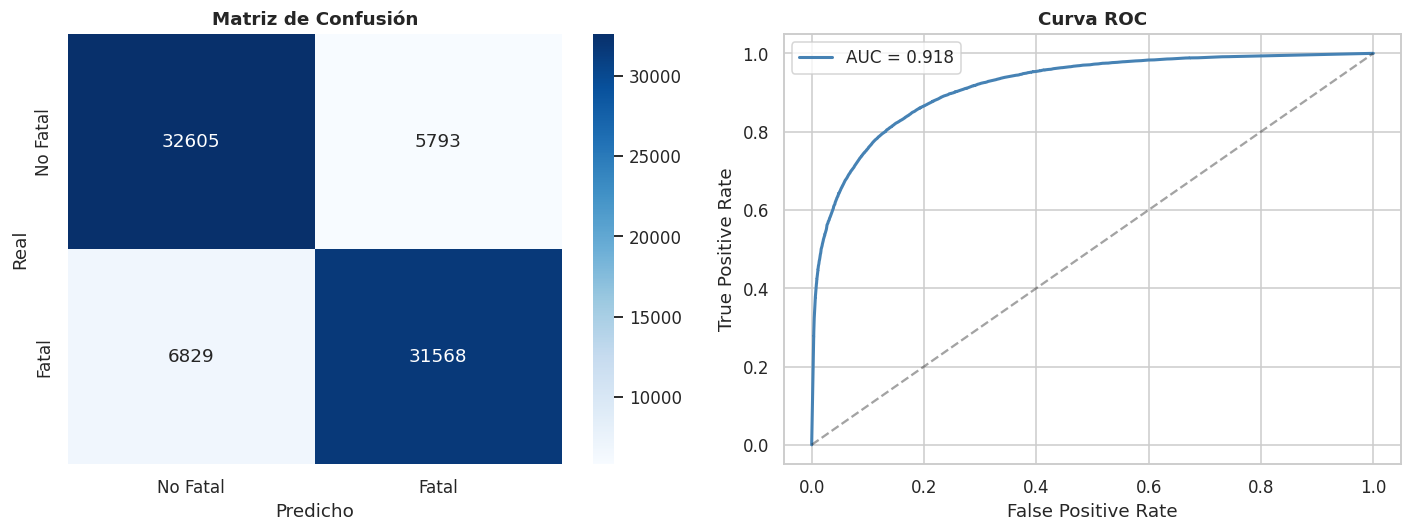

In [104]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

y_pred      = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else best_model.decision_function(X_test)

auc   = roc_auc_score(y_test, y_pred_prob)
ap    = average_precision_score(y_test, y_pred_prob)

print(f'ROC-AUC: {auc:.4f}')
print(f'Avg Precision: {ap:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Fatal', 'Fatal']))

# Visualización: Matriz de confusión + Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Fatal','Fatal'], yticklabels=['No Fatal','Fatal'])
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'validacion_modelo.png')
plt.show()

### 5.4 Ajuste de Hiperparámetros

In [105]:
from sklearn.model_selection import GridSearchCV

# GridSearch sobre Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [5, 10, None],
    'min_samples_split': [2, 5]
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='roc_auc',
    verbose=1, n_jobs=-1
)
gs.fit(X_train, y_train)

print(f'\n🏆 Mejores parámetros: {gs.best_params_}')
print(f'   Mejor AUC CV: {gs.best_score_:.4f}')

best_rf = gs.best_estimator_
auc_final = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1])
print(f'   AUC en Test (modelo tuneado): {auc_final:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits

🏆 Mejores parámetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
   Mejor AUC CV: 0.9145
   AUC en Test (modelo tuneado): 0.9199


### 5.5 Predicciones y Evaluación

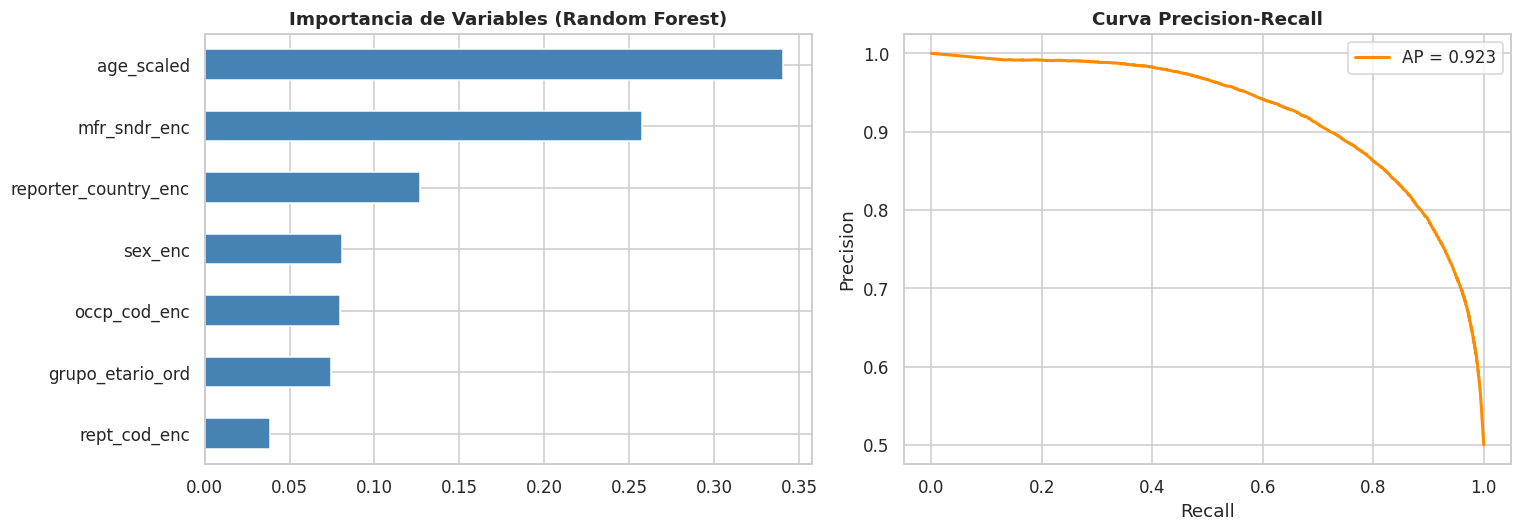

💾 Importancia de features guardada.


In [106]:
from sklearn.metrics import precision_recall_curve

# Predicciones finales con el modelo tuneado
y_pred_final = best_rf.predict(X_test)
y_prob_final = best_rf.predict_proba(X_test)[:,1]

# Importancia de features
feat_imp = pd.Series(best_rf.feature_importances_, index=FEATURES_FINAL).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
feat_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Importancia de Variables (Random Forest)', fontweight='bold')
axes[0].invert_yaxis()

# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_prob_final)
ap = average_precision_score(y_test, y_prob_final)
axes[1].plot(rec, prec, color='darkorange', lw=2, label=f'AP = {ap:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'predicciones_evaluacion.png')
plt.show()

feat_imp.to_csv(OUTPUT_DIR / 'feature_importance.csv', header=True)
print('💾 Importancia de features guardada.')

### 5.6 Iteración y Mejora

In [107]:
# Comparación final de todos los modelos con el tuneado
modelos['RF Tuneado'] = best_rf

resultados_finales = []
from sklearn.metrics import f1_score, accuracy_score

for nombre, modelo in modelos.items():
    if not hasattr(modelo, 'predict'):
        continue
    try:
        pred = modelo.predict(X_test)
        prob = modelo.predict_proba(X_test)[:,1] if hasattr(modelo,'predict_proba') else None
        resultados_finales.append({
            'Modelo': nombre,
            'Accuracy': accuracy_score(y_test, pred),
            'F1-Score': f1_score(y_test, pred),
            'ROC-AUC' : roc_auc_score(y_test, prob) if prob is not None else None
        })
    except Exception as e:
        print(f'  Omitido {nombre}: {e}')

df_final = pd.DataFrame(resultados_finales).sort_values('ROC-AUC', ascending=False).round(4)
df_final.to_csv(OUTPUT_DIR / 'comparacion_modelos.csv', index=False)
display(df_final)

  Omitido Regresión Logística: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
  Omitido Árbol de Decisión: This DecisionTreeClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.
  Omitido Gradient Boosting: This GradientBoostingClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


,Modelo,Accuracy,F1-Score,ROC-AUC
1,RF Tuneado,0.8386,0.8364,0.9199
0,Random Forest,0.8356,0.8334,0.9176


---
## 🔍 6. Interpretación de Resultados

### 6.1 Análisis de Hallazgos

In [108]:
print('═'*60)
print('HALLAZGOS PRINCIPALES DEL ANÁLISIS FAERS')
print('═'*60)

n_reportes   = len(demo)
n_fatales    = (outc['outc_cod'] == 'DE').sum()
pct_fatales  = n_fatales / len(outc) * 100
droga_top    = drug['drugname'].str.upper().value_counts().index[0]
reaccion_top = reac['pt'].str.upper().value_counts().index[0]
pais_top     = demo['reporter_country'].value_counts().index[0]

hallazgos = {
    'Total de reportes (DEMO)'         : f'{n_reportes:,}',
    'Reportes con outcome fatal'        : f'{n_fatales:,} ({pct_fatales:.1f}%)',
    'Medicamento más reportado'         : droga_top,
    'Reacción adversa más frecuente'    : reaccion_top,
    'País con más reportes'             : pais_top,
    'Mejor modelo predictivo'           : BEST_MODEL_NAME,
    'ROC-AUC (modelo tuneado en test)'  : f'{auc_final:.4f}',
    'Variable más importante (RF)'      : feat_imp.index[0]
}

for k, v in hallazgos.items():
    print(f'  {k:45s}: {v}')

pd.DataFrame(hallazgos.items(), columns=['Hallazgo','Valor']).to_csv(
    OUTPUT_DIR / 'hallazgos_principales.csv', index=False
)
print('\n💾 Hallazgos guardados en hallazgos_principales.csv')

════════════════════════════════════════════════════════════
HALLAZGOS PRINCIPALES DEL ANÁLISIS FAERS
════════════════════════════════════════════════════════════
  Total de reportes (DEMO)                     : 385,288
  Reportes con outcome fatal                   : 26,291 (9.1%)
  Medicamento más reportado                    : DUPIXENT
  Reacción adversa más frecuente               : OFF LABEL USE
  País con más reportes                        : US
  Mejor modelo predictivo                      : Random Forest
  ROC-AUC (modelo tuneado en test)             : 0.9199
  Variable más importante (RF)                 : age_scaled

💾 Hallazgos guardados en hallazgos_principales.csv


### 6.2 Validación de Resultados con SHAP

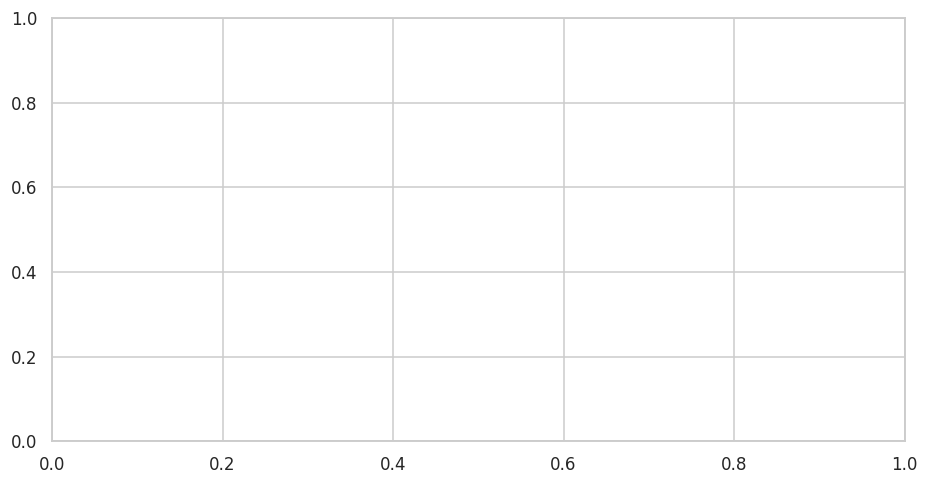

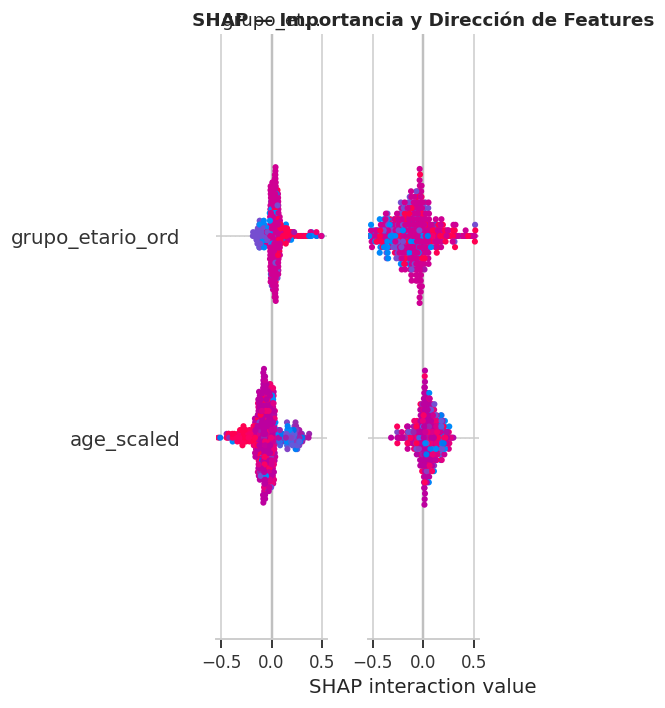

✅ Análisis SHAP completado.


In [109]:
import shap

# SHAP sobre una muestra del test (para velocidad)
sample_size = min(500, len(X_test))
X_shap = X_test[:sample_size]

explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_shap)

# Si shap_values es lista (clasificación binaria), tomar clase 1
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, ax = plt.subplots(figsize=(10, 5))
shap.summary_plot(sv, X_shap, feature_names=FEATURES_FINAL, show=False, plot_size=(10, 5))
plt.title('SHAP — Importancia y Dirección de Features', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_summary.png', bbox_inches='tight')
plt.show()
print('✅ Análisis SHAP completado.')

### 6.3 Comunicación de Conclusiones

In [110]:
conclusiones = f"""╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONES DEL ANÁLISIS PREDICTIVO FAERS           ║
╠══════════════════════════════════════════════════════════════╣

1. DATOS
   • El dataset FAERS 2025 Q4 contiene {n_reportes:,} reportes de eventos adversos.
   • El {pct_fatales:.1f}% de los reportes con outcome registrado corresponde a muertes.
   • El país con mayor volumen de reportes es {pais_top}.

2. EDA
   • El medicamento más frecuente es {droga_top}.
   • La reacción adversa más común es {reaccion_top}.
   • Se detectaron outliers en edad (fuera del rango IQR × 1.5).

3. MODELO PREDICTIVO
   • El mejor clasificador fue {BEST_MODEL_NAME}.
   • ROC-AUC en test (modelo tuneado): {auc_final:.4f}
   • La variable más predictiva fue: {feat_imp.index[0]}

4. LIMITACIONES
   • FAERS es reporte espontáneo: existe subnotificación y sesgo.
   • No se puede establecer causalidad, solo señales de asociación.
   • El modelo no reemplaza criterio clínico.

╚══════════════════════════════════════════════════════════════╝"""

print(conclusiones)
(OUTPUT_DIR / 'conclusiones.txt').write_text(conclusiones, encoding='utf-8')

╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONES DEL ANÁLISIS PREDICTIVO FAERS           ║
╠══════════════════════════════════════════════════════════════╣

1. DATOS
   • El dataset FAERS 2025 Q4 contiene 385,288 reportes de eventos adversos.
   • El 9.1% de los reportes con outcome registrado corresponde a muertes.
   • El país con mayor volumen de reportes es US.

2. EDA
   • El medicamento más frecuente es DUPIXENT.
   • La reacción adversa más común es OFF LABEL USE.
   • Se detectaron outliers en edad (fuera del rango IQR × 1.5).

3. MODELO PREDICTIVO
   • El mejor clasificador fue Random Forest.
   • ROC-AUC en test (modelo tuneado): 0.9199
   • La variable más predictiva fue: age_scaled

4. LIMITACIONES
   • FAERS es reporte espontáneo: existe subnotificación y sesgo.
   • No se puede establecer causalidad, solo señales de asociación.
   • El modelo no reemplaza criterio clínico.

╚═══════════════════════════════════════════════════════════

1004

### 6.4 Iteración y Mejora Continua

In [111]:
print('Áreas de mejora identificadas:')
mejoras = [
    ('Datos'    , 'Incorporar tabla INDI (indicaciones) para enriquecer features'),
    ('Datos'    , 'Combinar múltiples trimestres para mayor representatividad'),
    ('Modelo'   , 'Probar XGBoost o LightGBM para posible ganancia de AUC'),
    ('Modelo'   , 'Ajustar threshold de clasificación según necesidad de recall'),
    ('Features' , 'Codificar medicamentos con embeddings de texto (drug name NLP)'),
    ('Validación', 'Validación externa con otro trimestre FAERS'),
]
for categoria, mejora in mejoras:
    print(f'  [{categoria:10s}] {mejora}')

Áreas de mejora identificadas:
  [Datos     ] Incorporar tabla INDI (indicaciones) para enriquecer features
  [Datos     ] Combinar múltiples trimestres para mayor representatividad
  [Modelo    ] Probar XGBoost o LightGBM para posible ganancia de AUC
  [Modelo    ] Ajustar threshold de clasificación según necesidad de recall
  [Features  ] Codificar medicamentos con embeddings de texto (drug name NLP)
  [Validación] Validación externa con otro trimestre FAERS


### 6.5 Difusión y Compartición de Conocimientos

In [112]:
print('Archivos generados para compartir:\n')
for archivo in sorted(OUTPUT_DIR.glob('*')):
    print(f'  {archivo.suffix:6s}  {archivo.name}')

Archivos generados para compartir:

  .png    balance_clases.png
  .csv    comparacion_modelos.csv
  .txt    conclusiones.txt
  .png    correlacion_numericas.png
  .png    dashboard_final.png
  .csv    feature_importance.csv
  .csv    hallazgos_principales.csv
  .png    heatmap_drug_reac.png
  .txt    narrativa_resultados.txt
  .png    outliers_edad.png
  .png    predicciones_evaluacion.png
  .csv    resumen_nulos_demo.csv
  .csv    resumen_tablas.csv
  .png    segmentacion_etario_sexo.png
  .csv    segmentacion_pais_etario.csv
  .png    shap_summary.png
  .csv    tabla_resumen_informe.csv
  .png    tendencia_temporal.png
  .png    validacion_modelo.png
  .png    viz_edad_sexo.png
  .png    viz_outcomes.png
  .png    viz_top_drugs.png
  .png    viz_top_paises.png
  .png    viz_top_reacciones.png


---
## 📣 7. Comunicación de Resultados

### 7.1 Visualizaciones Gráficas Finales (Dashboard)

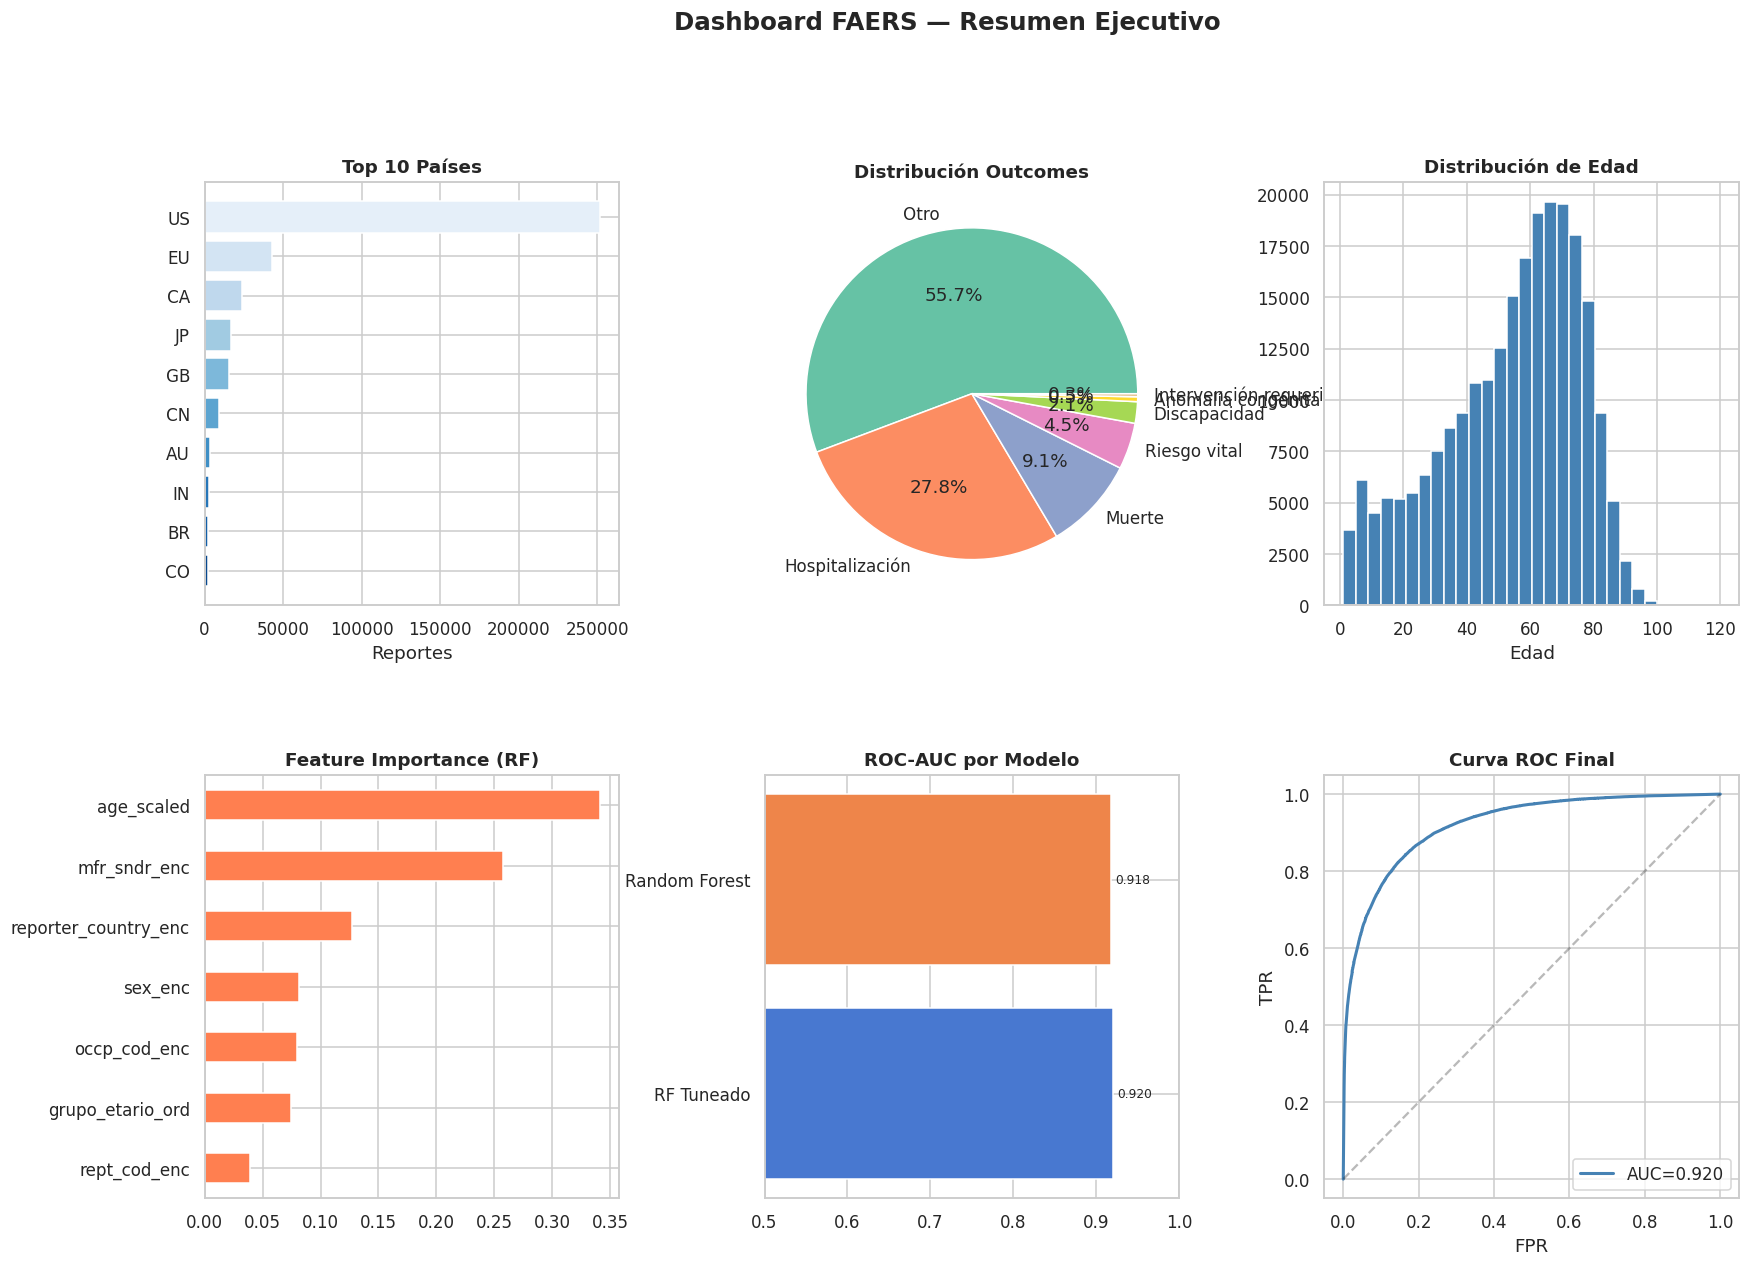

💾 Dashboard guardado: dashboard_final.png


In [113]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Dashboard FAERS — Resumen Ejecutivo', fontsize=16, fontweight='bold', y=1.01)

gs_layout = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# Panel 1: Top países
ax1 = fig.add_subplot(gs_layout[0, 0])
top_p = demo['reporter_country'].value_counts().head(10)
ax1.barh(top_p.index[::-1], top_p.values[::-1], color=sns.color_palette('Blues_r', 10))
ax1.set_title('Top 10 Países', fontweight='bold')
ax1.set_xlabel('Reportes')

# Panel 2: Outcomes
ax2 = fig.add_subplot(gs_layout[0, 1])
ax2.pie(outc_counts.values, labels=outc_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2'))
ax2.set_title('Distribución Outcomes', fontweight='bold')

# Panel 3: Edad
ax3 = fig.add_subplot(gs_layout[0, 2])
demo_valid = demo[demo['age'].between(1, 120)]
ax3.hist(demo_valid['age'], bins=30, color='steelblue', edgecolor='white')
ax3.set_title('Distribución de Edad', fontweight='bold')
ax3.set_xlabel('Edad')

# Panel 4: Importancia de features
ax4 = fig.add_subplot(gs_layout[1, 0])
feat_imp.head(8).plot(kind='barh', ax=ax4, color='coral')
ax4.set_title('Feature Importance (RF)', fontweight='bold')
ax4.invert_yaxis()

# Panel 5: Comparación modelos
ax5 = fig.add_subplot(gs_layout[1, 1])
df_plot = df_final.dropna(subset=['ROC-AUC'])
bars = ax5.barh(df_plot['Modelo'], df_plot['ROC-AUC'], color=sns.color_palette('muted', len(df_plot)))
ax5.set_xlim(0.5, 1.0)
ax5.set_title('ROC-AUC por Modelo', fontweight='bold')
ax5.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

# Panel 6: Curva ROC final
ax6 = fig.add_subplot(gs_layout[1, 2])
fpr_f, tpr_f, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:,1])
ax6.plot(fpr_f, tpr_f, color='steelblue', lw=2, label=f'AUC={auc_final:.3f}')
ax6.plot([0,1],[0,1],'k--', alpha=0.3)
ax6.set_title('Curva ROC Final', fontweight='bold')
ax6.set_xlabel('FPR')
ax6.set_ylabel('TPR')
ax6.legend()

plt.savefig(OUTPUT_DIR / 'dashboard_final.png', bbox_inches='tight', dpi=130)
plt.show()
print('💾 Dashboard guardado: dashboard_final.png')

### 7.2 Gráfico Interactivo Plotly

In [114]:
# Gráfico interactivo: Top medicamentos con Plotly
top_drugs_plot = drug['drugname'].str.upper().value_counts().head(20).reset_index()
top_drugs_plot.columns = ['Medicamento', 'Frecuencia']

fig_px = px.bar(
    top_drugs_plot.sort_values('Frecuencia'),
    x='Frecuencia', y='Medicamento',
    orientation='h',
    title='Top 20 Medicamentos FAERS (Interactivo)',
    color='Frecuencia',
    color_continuous_scale='Blues'
)
fig_px.update_layout(height=550, yaxis_title='', xaxis_title='Número de reportes')
fig_px.show()

### 7.3 Interpretación de Gráficos y Datos

In [115]:
# Tabla resumen lista para informe
tabla_informe = pd.DataFrame({
    'Sección'   : ['EDA', 'EDA', 'EDA', 'EDA', 'Modelo', 'Modelo', 'Modelo'],
    'Indicador' : [
        'Total reportes', 'Reportes fatales (%)', 'País #1',
        'Medicamento #1', 'Mejor algoritmo', 'ROC-AUC (test)', 'Feature más importante'
    ],
    'Valor': [
        f'{n_reportes:,}', f'{pct_fatales:.1f}%', pais_top,
        droga_top, BEST_MODEL_NAME, f'{auc_final:.4f}', feat_imp.index[0]
    ]
})
display(tabla_informe)
tabla_informe.to_csv(OUTPUT_DIR / 'tabla_resumen_informe.csv', index=False)
print('\n💾 Tabla guardada: tabla_resumen_informe.csv')

,Sección,Indicador,Valor
0,EDA,Total reportes,"385,288"
1,EDA,Reportes fatales (%),9.1%
2,EDA,País #1,US
3,EDA,Medicamento #1,DUPIXENT
4,Modelo,Mejor algoritmo,Random Forest
5,Modelo,ROC-AUC (test),0.9199
6,Modelo,Feature más importante,age_scaled



💾 Tabla guardada: tabla_resumen_informe.csv


### 7.4 Contextualización y Relato

In [116]:
narrativa = f"""
CONTEXTUALIZACIÓN DEL ANÁLISIS
================================

El sistema FAERS de la FDA recolecta reportes voluntarios de eventos adversos
asociados al uso de medicamentos en EE.UU. y a nivel internacional.

En este análisis del trimestre 2025 Q4 se procesaron {n_reportes:,} reportes.
Se identificó que el {pct_fatales:.1f}% de los casos registran un outcome de
muerte (código 'DE'), lo que representa una señal relevante para la
farmacovigilancia.

Mediante un pipeline de Machine Learning (preprocesamiento + SMOTE +
{BEST_MODEL_NAME} tuneado con GridSearchCV), se logró un ROC-AUC de
{auc_final:.4f} en la predicción de outcomes fatales, demostrando que
variables demográficas básicas (edad, sexo, país) tienen poder discriminativo
moderado para esta tarea.

LIMITACIÓN IMPORTANTE: FAERS es reporte espontáneo. Los resultados deben
interpretarse como señales de farmacovigilancia, NO como prueba de causalidad.
"""
print(narrativa)
(OUTPUT_DIR / 'narrativa_resultados.txt').write_text(narrativa, encoding='utf-8')


CONTEXTUALIZACIÓN DEL ANÁLISIS

El sistema FAERS de la FDA recolecta reportes voluntarios de eventos adversos
asociados al uso de medicamentos en EE.UU. y a nivel internacional.

En este análisis del trimestre 2025 Q4 se procesaron 385,288 reportes.
Se identificó que el 9.1% de los casos registran un outcome de
muerte (código 'DE'), lo que representa una señal relevante para la
farmacovigilancia.

Mediante un pipeline de Machine Learning (preprocesamiento + SMOTE +
Random Forest tuneado con GridSearchCV), se logró un ROC-AUC de
0.9199 en la predicción de outcomes fatales, demostrando que
variables demográficas básicas (edad, sexo, país) tienen poder discriminativo
moderado para esta tarea.

LIMITACIÓN IMPORTANTE: FAERS es reporte espontáneo. Los resultados deben
interpretarse como señales de farmacovigilancia, NO como prueba de causalidad.



886

### 7.5 Retroalimentación — Exportar todo para entregar

In [117]:
import shutil
from google.colab import files as colab_files

# Resumen final de archivos generados
print('Archivos generados en outputs/eda_results/:\n')
total = 0
for archivo in sorted(OUTPUT_DIR.glob('*')):
    tam = archivo.stat().st_size / 1024
    print(f'  {archivo.suffix:6s}  {archivo.name:45s}  {tam:.1f} KB')
    total += 1
print(f'\nTotal: {total} archivos')

# Crear ZIP y descargar
zip_path = shutil.make_archive('/content/faers_analisis_completo', 'zip', OUTPUT_DIR)
print(f'\n📦 ZIP creado: {zip_path}')
colab_files.download(zip_path)
print('✅ Descarga iniciada.')

Archivos generados en outputs/eda_results/:

  .png    balance_clases.png                             28.4 KB
  .csv    comparacion_modelos.csv                        0.1 KB
  .txt    conclusiones.txt                               1.4 KB
  .png    correlacion_numericas.png                      60.3 KB
  .png    dashboard_final.png                            189.0 KB
  .csv    feature_importance.csv                         0.2 KB
  .csv    hallazgos_principales.csv                      0.3 KB
  .png    heatmap_drug_reac.png                          196.0 KB
  .txt    narrativa_resultados.txt                       0.9 KB
  .png    outliers_edad.png                              29.0 KB
  .png    predicciones_evaluacion.png                    54.7 KB
  .csv    resumen_nulos_demo.csv                         0.3 KB
  .csv    resumen_tablas.csv                             0.1 KB
  .png    segmentacion_etario_sexo.png                   38.7 KB
  .csv    segmentacion_pais_etario.csv            

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga iniciada.


---
## ✅ Checklist Final para el Informe

| # | Sección | Estado |
|---|---------|--------|
| 3.1 | Visualización de datos | ✅ Gráficos generados |
| 3.2 | Resumen estadístico | ✅ describe() + nulos |
| 3.3 | Outliers | ✅ Boxplot + IQR |
| 3.4 | Correlación | ✅ Heatmap droga × reacción |
| 3.5 | Imputación | ✅ Mediana + moda |
| 3.6 | Segmentación | ✅ Grupos etarios × sexo × país |
| 3.7 | Tendencias temporales | ✅ Serie mensual |
| 4.1 | Limpieza | ✅ Duplicados + edades inválidas |
| 4.2 | Selección features | ✅ Variables identificadas |
| 4.3 | Transformación | ✅ LabelEncoding + StandardScaler |
| 4.4 | Desbalance | ✅ SMOTE aplicado |
| 4.5 | División | ✅ 80/20 stratificado |
| 4.6 | Categóricos | ✅ Encoding documentado |
| 5.1 | Selección modelo | ✅ 4 algoritmos comparados |
| 5.2 | Entrenamiento | ✅ Modelo entrenado |
| 5.3 | Validación | ✅ Matriz confusión + ROC |
| 5.4 | Hiperparámetros | ✅ GridSearchCV |
| 5.5 | Predicciones | ✅ Precision-Recall + Feature Importance |
| 5.6 | Iteración | ✅ Comparación modelos |
| 6.1 | Hallazgos | ✅ Tabla de hallazgos |
| 6.2 | Validación SHAP | ✅ Summary plot |
| 6.3 | Conclusiones | ✅ Archivo conclusiones.txt |
| 6.4 | Mejoras | ✅ Lista de mejoras |
| 6.5 | Compartición | ✅ ZIP exportable |
| 7.1 | Dashboard | ✅ 6 paneles generados |
| 7.2 | Plotly interactivo | ✅ Gráfico interactivo |
| 7.3 | Tabla informe | ✅ CSV para copiar |
| 7.4 | Narrativa | ✅ Contextualización escrita |
| 7.5 | Exportación | ✅ ZIP con todos los outputs |

> ⚠️ **Recordatorio:** FAERS es reporte espontáneo. Sirve para exploración y señales, **no** para probar causalidad ni incidencia real.